In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [31]:
print(df.info())
cols = df.columns
cols
for i in cols:
    #print(f"Missing values count of {i}: {df[i].isna().sum()}")
    print(f"Missing values percentage of {i} : {(df[i].isna().sum()/len(df)):.2%}")

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       200 non-null    int64  
 1   city           200 non-null    str    
 2   category       200 non-null    str    
 3   order_value    186 non-null    float64
 4   delivery_days  190 non-null    float64
 5   rating         168 non-null    object 
dtypes: float64(2), int64(1), object(1), str(2)
memory usage: 9.5+ KB
None
Missing values percentage of order_id : 0.00%
Missing values percentage of city : 0.00%
Missing values percentage of category : 0.00%
Missing values percentage of order_value : 7.00%
Missing values percentage of delivery_days : 5.00%
Missing values percentage of rating : 16.00%


In [32]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


#### Observation form the previous Output
1. Standard deviation of order_value column is very high, meaning, the values are high;ly scattered.
2. Oder value colum shows a high gap between 75th percentile nad max value.

In [42]:
from matplotlib import pyplot as ply
import seaborn as sbn

Text(0, 0.5, 'Frequency')

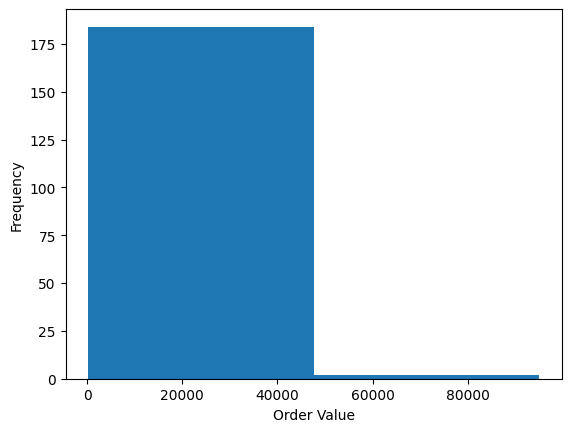

In [41]:
ply.hist(df['order_value'],bins=2)
ply.xlabel("Order Value")
ply.ylabel("Frequency")

<Axes: ylabel='delivery_days'>

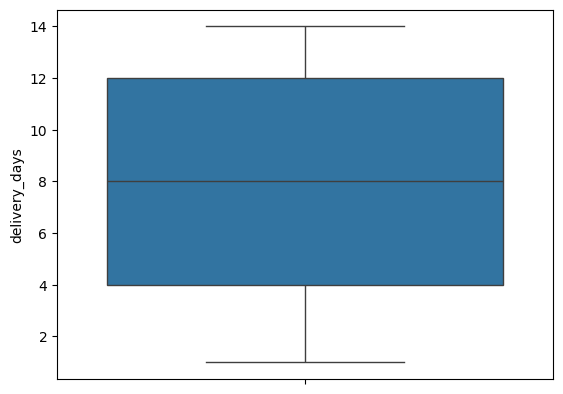

In [43]:
sbn.boxplot(data=df,y=df['delivery_days'])

corr_matrix:                order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


<Axes: >

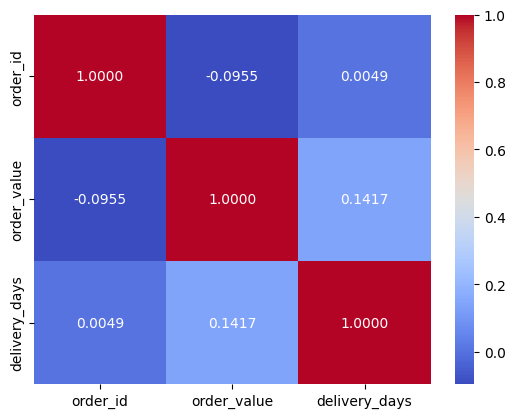

In [56]:
numeric_cols = df.select_dtypes(include="number")
corr_matrix=numeric_cols.corr()
print(f"corr_matrix: {corr_matrix}")

sbn.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".4f")

There is a strong negative correlation between delivery days and order_id. But there is a no meaning in having a correlation between orderid and any other numeric values.